### Scott 10k OvR

#### OvR classification (with LR + XGB for SHAP analysis) for AD vs not AD, MCI vs not MCI, CN vs not CN 
#### Then, feature select for each situation, and get metrics there

DIAGNOSIS
2.0    5056
1.0    4035
3.0    2835
Name: count, dtype: int64
DIAGNOSIS
0    9091
1    2835
Name: count, dtype: int64
DIAGNOSIS
0    6870
1    5056
Name: count, dtype: int64
DIAGNOSIS
0.0    7891
1.0    4035
Name: count, dtype: int64
3.2067019400352734
Fold 0 - ad_ovr
Fold 1 - ad_ovr
Fold 2 - ad_ovr
Fold 3 - ad_ovr
Fold 4 - ad_ovr
[   0    1    2 ... 4768 4769 4770]
[   0    1    2 ... 7153 7154 7155]
[   0    1    2 ... 9538 9539 9540]
[    0     1     2 ... 11923 11924 11925]
XGB SHAP INCOMING...
(11926, 19)


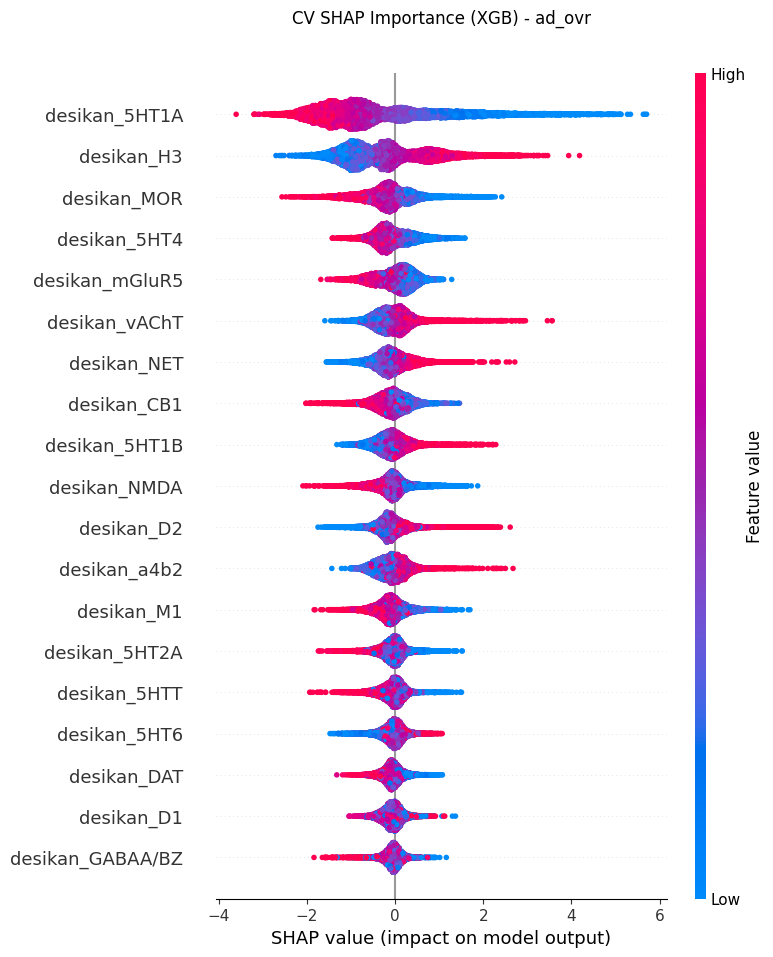

{'Ad_ovr LR accuracy': [0.7921207041072925, 0.7492662473794549, 0.7643605870020964, 0.8012578616352202, 0.8142557651991614], 'Ad_ovr XGB accuracy': [0.7950544844928751, 0.7861635220125787, 0.7815513626834382, 0.8209643605870021, 0.8159329140461216], 'Ad_ovr LR F1': [0.6565096952908587, 0.6358099878197321, 0.6171662125340599, 0.6325581395348837, 0.6041108132260947], 'Ad_ovr XGB F1': [0.5928393005828476, 0.6142208774583964, 0.5543199315654406, 0.6027906976744186, 0.5264293419633226], 'Ad_ovr LR Sensitivity': [0.797979797979798, 0.7653958944281525, 0.798941798941799, 0.807920792079208, 0.6940451745379876], 'Ad_ovr XGB Sensitivity': [0.5993265993265994, 0.5953079178885631, 0.5714285714285714, 0.6415841584158416, 0.5010266940451745], 'Ad_ovr LR AUC-PR': [0.723703173246045, 0.70281419625322, 0.66755003488874, 0.6811096959235362, 0.6206407556641168], 'Ad_ovr XGB AUC-PR': [0.6100381710544152, 0.6349342204123807, 0.5975309438345843, 0.6271913250760573, 0.5520973117959745]}
Ad_ovr LR accuracy 5


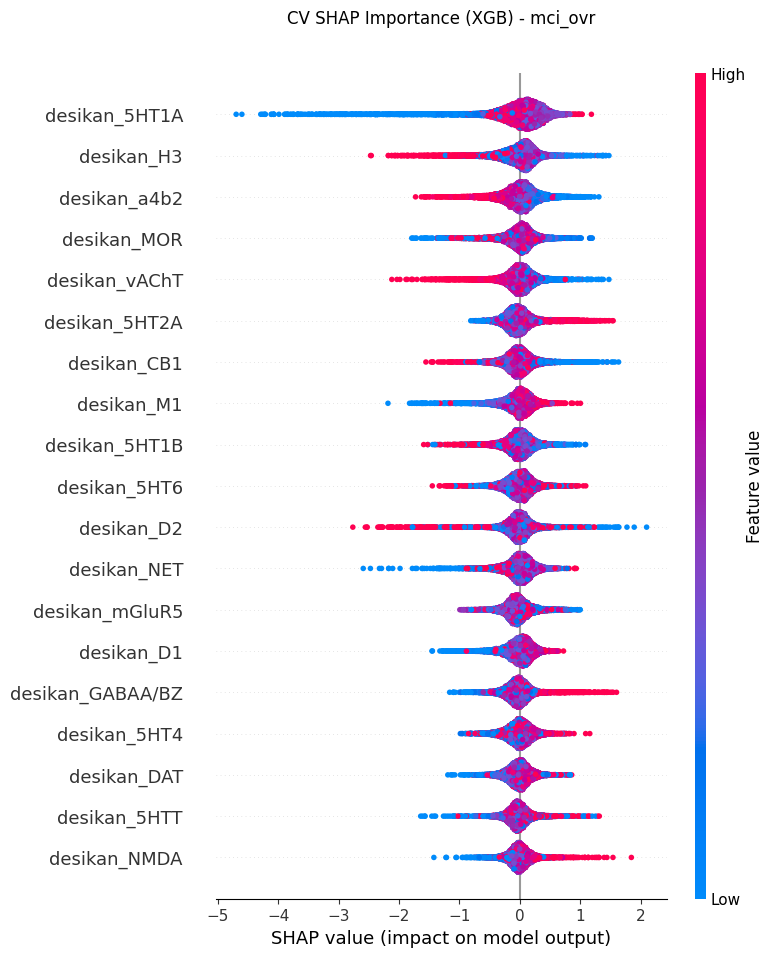

{'Mci_ovr LR accuracy': [0.5020955574182733, 0.5379454926624738, 0.5333333333333333, 0.5371069182389937, 0.4880503144654088], 'Mci_ovr XGB accuracy': [0.5406538139145013, 0.5660377358490566, 0.5283018867924528, 0.529979035639413, 0.5228511530398323], 'Mci_ovr LR F1': [0.4358974358974359, 0.4864864864864865, 0.49015116811726983, 0.5212489158716392, 0.46282446106467223], 'Mci_ovr XGB F1': [0.44646464646464645, 0.4848183175709308, 0.43267776096822996, 0.44532409698169223, 0.442156862745098], 'Mci_ovr LR Sensitivity': [0.5021881838074398, 0.5409326424870466, 0.5194174757281553, 0.563261480787254, 0.48703703703703705], 'Mci_ovr XGB Sensitivity': [0.48358862144420134, 0.5046632124352332, 0.41650485436893203, 0.4217432052483599, 0.41759259259259257], 'Mci_ovr LR AUC-PR': [0.3946413453491613, 0.44808139411282044, 0.47110920601328937, 0.5039355777908607, 0.4617697185002734], 'Mci_ovr XGB AUC-PR': [0.41451569322814386, 0.4771342132569997, 0.46157403115804585, 0.48296668076638644, 0.4695284114577

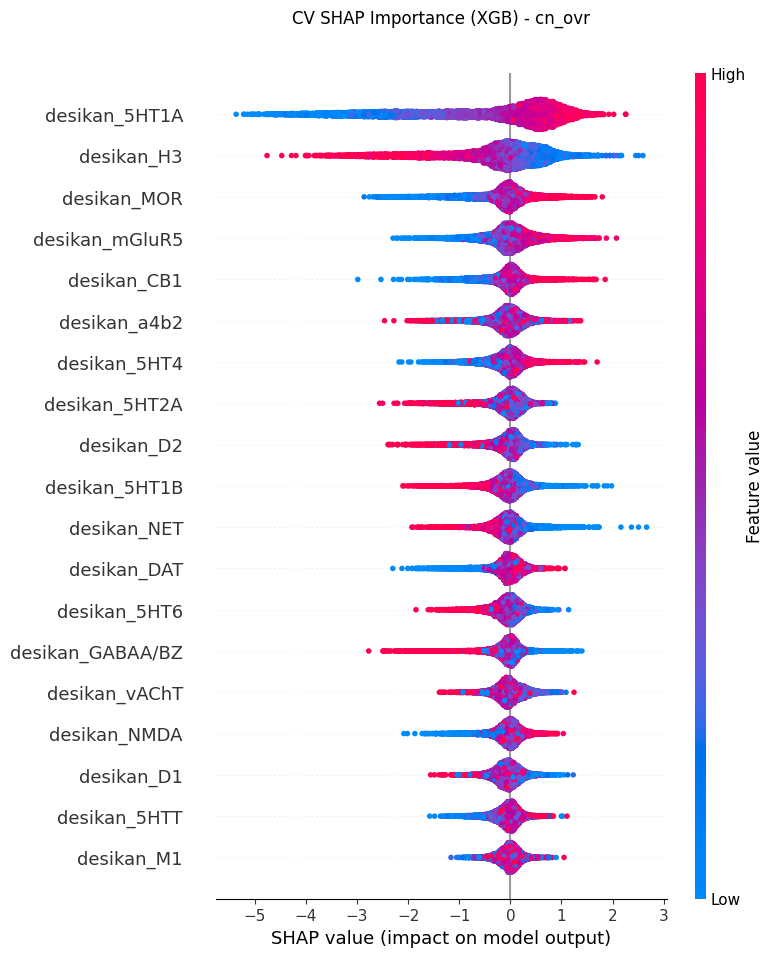

{'Cn_ovr LR accuracy': [0.7246437552388936, 0.7224318658280923, 0.6926624737945493, 0.6691823899371069, 0.6255765199161426], 'Cn_ovr XGB accuracy': [0.6965632858340318, 0.7161425576519916, 0.680083857442348, 0.6691823899371069, 0.6381551362683439], 'Cn_ovr LR F1': [0.6812227074235808, 0.6338495575221239, 0.6246799795186891, 0.6145578895945286, 0.5927952576379389], 'Cn_ovr XGB F1': [0.5695600475624257, 0.5531353135313531, 0.551967116852613, 0.5383265067290813, 0.5332612222823148], 'Cn_ovr LR Sensitivity': [0.7995444191343963, 0.7764227642276422, 0.7741116751269036, 0.7736777367773677, 0.7946210268948656], 'Cn_ovr XGB Sensitivity': [0.5455580865603644, 0.5677506775067751, 0.5964467005076142, 0.5658056580565806, 0.6026894865525673], 'Cn_ovr LR AUC-PR': [0.6315571612614541, 0.5701840379071623, 0.5514561803981733, 0.48567609980156146, 0.47933117277228005], 'Cn_ovr XGB AUC-PR': [0.6244991932206864, 0.5321529959243116, 0.5290788396094559, 0.50482587208862, 0.47522037017086716]}
Cn_ovr LR accu

In [1]:
import pandas as pd
import numpy as np
import os
import sklearn
import shap
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import precision_recall_curve, auc, accuracy_score, f1_score, recall_score, average_precision_score
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score 
from matplotlib import font_manager

font_path = "/rds/general/user/sk4724/home/arial.ttf"
font_manager.fontManager.addfont(font_path)

df = pd.read_csv('/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/sbm_w_vbm_scott10k_alliedhealth.csv', low_memory = False)

selected_cols = ['desikan_D1', 'desikan_D2', 'desikan_DAT', 'desikan_NET', 'desikan_5HT1A', 'desikan_5HT1B', 'desikan_5HT2A', 'desikan_5HT4', 'desikan_5HT6', 'desikan_5HTT', 'desikan_a4b2', 'desikan_M1', 'desikan_vAChT', 'desikan_NMDA',	'desikan_mGluR5', 'desikan_GABAA/BZ', 'desikan_H3', 'desikan_CB1', 'desikan_MOR']

df = df[['DIAGNOSIS'] + selected_cols].dropna()

print(df['DIAGNOSIS'].value_counts())

assert df.isna().values.any() == False

## OvR - AD vs non-AD

ad_ovr_df = df.copy()
ad_ovr_df['DIAGNOSIS'] = ad_ovr_df['DIAGNOSIS'].apply(lambda x: 1 if x == 3 else 0)
print(ad_ovr_df['DIAGNOSIS'].value_counts())

ad_ovr_X = ad_ovr_df.drop(columns = 'DIAGNOSIS')
ad_ovr_y = ad_ovr_df['DIAGNOSIS']

## OvR - MCI vs non-MCI

mci_ovr_df = df.copy()
mci_ovr_df['DIAGNOSIS'] = mci_ovr_df['DIAGNOSIS'].apply(lambda x: 1 if x == 2 else 0)
print(mci_ovr_df['DIAGNOSIS'].value_counts())

mci_ovr_X = mci_ovr_df.drop(columns = 'DIAGNOSIS')
mci_ovr_y = mci_ovr_df['DIAGNOSIS']

## OvR - CN vs non-CN

cn_ovr_df = df.copy()
cn_ovr_df['DIAGNOSIS'] = cn_ovr_df['DIAGNOSIS'].apply(lambda x: x if x == 1 else 0)
print(cn_ovr_df['DIAGNOSIS'].value_counts())

cn_ovr_X = cn_ovr_df.drop(columns = 'DIAGNOSIS')
cn_ovr_y = cn_ovr_df['DIAGNOSIS']

## Prelims

scaler = StandardScaler()

seed = 42

kf = KFold()

lr = LogisticRegression(random_state = seed, class_weight = 'balanced')

for X, y, flag in [(ad_ovr_X, ad_ovr_y, 'ad_ovr'), (mci_ovr_X, mci_ovr_y, 'mci_ovr'), (cn_ovr_X, cn_ovr_y, 'cn_ovr')]:
    
    xgb_balancer = float(y[y == 0].shape[0])/ float(y[y == 1].shape[0])
    print(xgb_balancer)

    ## Instantiate xgb with the balancer - mitigates class imbalance

    xgb = XGBClassifier(random_state = seed, scale_pos_weight = xgb_balancer)
    
    accuracies_lr = []
    f1_scores_lr = []
    sensitivities_lr = []
    aucprs_lr = []
    
    accuracies_xgb = []
    f1_scores_xgb = []
    sensitivities_xgb = []
    aucprs_xgb = []
    
    list_test_sets = list()
    
    list_shap_values_xgb = list()
    
    list_X_test_scaled = []

    for i, (train_index, test_index) in enumerate(kf.split(X)):
        print(f"Fold {i} - {flag}")
    
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train,y_test = y.iloc[train_index], y.iloc[test_index]
    
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
        list_X_test_scaled.append(X_test)
            
        lr.fit(X_train, y_train)
        xgb.fit(X_train, y_train)
    
        lr_pred_diags = lr.predict(X_test)
        xgb_pred_diags = xgb.predict(X_test)
    
        lr_pred_probas = lr.predict_proba(X_test)[:,1]
        xgb_pred_probas = xgb.predict_proba(X_test)[:,1]
    
        precision_lr, recall_lr, thresholds_lr = precision_recall_curve(y_test, lr_pred_probas)
        precision_xgb, recall_xgb, thresholds_xgb = precision_recall_curve(y_test, xgb_pred_probas)
            
        aucpr_lr = auc(recall_lr, precision_lr)
        aucprs_lr.append(aucpr_lr)
        aucpr_xgb = auc(recall_xgb, precision_xgb)
        aucprs_xgb.append(aucpr_xgb)

        acc_lr = accuracy_score(y_test, lr_pred_diags)
        accuracies_lr.append(acc_lr)
        acc_xgb = accuracy_score(y_test, xgb_pred_diags)
        accuracies_xgb.append(acc_xgb)
        
        f1_lr = f1_score(y_test, lr_pred_diags)
        f1_scores_lr.append(f1_lr)
        f1_xgb = f1_score(y_test, xgb_pred_diags)
        f1_scores_xgb.append(f1_xgb)
        
        sensitivity_lr = recall_score(y_test, lr_pred_diags)
        sensitivities_lr.append(sensitivity_lr)
        sensitivity_xgb = recall_score(y_test, xgb_pred_diags)
        sensitivities_xgb.append(sensitivity_xgb)
        
        list_test_sets.append(test_index)# A list of the order of test set indexes
        
        xgb_explainer = shap.TreeExplainer(xgb)
        xgb_shap_values = xgb_explainer.shap_values(X_test)
        list_shap_values_xgb.append(xgb_shap_values) # A list of shap values

        test_set = list_test_sets[0]
        shap_values_xgb = np.array(list_shap_values_xgb[0])
        
        X_scaled_full = np.concatenate(list_X_test_scaled, axis=0)
    for n in range(1,len(list_test_sets)):
        test_set = np.concatenate((test_set,list_test_sets[n]),axis=0)
        print(test_set)
        shap_values_xgb = np.concatenate((shap_values_xgb, np.array(list_shap_values_xgb[n])),axis = 0)
            
    print('XGB SHAP INCOMING...')
    print(shap_values_xgb.shape)
    X_reordered = X.iloc[test_set]
    shap.summary_plot(shap_values_xgb, X_reordered, show=False)    
    plt.title(f'CV SHAP Importance (XGB) - {flag}', y=1.05)
    plt.savefig(f'/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/classifiers/xgb_shap_beeswarm_{flag}.png',dpi=600)
    plt.show()
    plt.close()

    flag_u = flag.capitalize()
    
    data = {
        f"{flag_u} LR accuracy": accuracies_lr,
        f"{flag_u} XGB accuracy": accuracies_xgb,
        f"{flag_u} LR F1": f1_scores_lr,
        f"{flag_u} XGB F1": f1_scores_xgb,
        f"{flag_u} LR Sensitivity": sensitivities_lr,
        f"{flag_u} XGB Sensitivity": sensitivities_xgb,
        f"{flag_u} LR AUC-PR": aucprs_lr,
        f"{flag_u} XGB AUC-PR": aucprs_xgb}
        
    print(data)
    
    for key, vals in data.items():
        print(key, len(vals))
    
    df = pd.DataFrame(data)
    
    print(df)
    
    df.to_csv(f'/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/classifiers/fold_metrics_{flag}.csv', index = False)

In [2]:
import pandas as pd
import numpy as np
import os
import sklearn
import shap
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import precision_recall_curve, auc, accuracy_score, f1_score, recall_score, average_precision_score, make_scorer
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import RFECV
from matplotlib import font_manager

font_path = "/rds/general/user/sk4724/home/arial.ttf"
font_manager.fontManager.addfont(font_path)

df = pd.read_csv('/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/sbm_w_vbm_scott10k_alliedhealth.csv', low_memory = False)

selected_cols = ['desikan_D1', 'desikan_D2', 'desikan_DAT', 'desikan_NET', 'desikan_5HT1A', 'desikan_5HT1B', 'desikan_5HT2A', 'desikan_5HT4', 'desikan_5HT6', 'desikan_5HTT', 'desikan_a4b2', 'desikan_M1', 'desikan_vAChT', 'desikan_NMDA',	'desikan_mGluR5', 'desikan_GABAA/BZ', 'desikan_H3', 'desikan_CB1', 'desikan_MOR']

df = df[['DIAGNOSIS'] + selected_cols].dropna()

print(df['DIAGNOSIS'].value_counts())

assert df.isna().values.any() == False

## OvR - AD vs non-AD

ad_ovr_df = df.copy()
ad_ovr_df['DIAGNOSIS'] = ad_ovr_df['DIAGNOSIS'].apply(lambda x: 1 if x == 3 else 0)
print(ad_ovr_df['DIAGNOSIS'].value_counts())

ad_ovr_X = ad_ovr_df.drop(columns = 'DIAGNOSIS')
ad_ovr_y = ad_ovr_df['DIAGNOSIS']

## OvR - MCI vs non-MCI

mci_ovr_df = df.copy()
mci_ovr_df['DIAGNOSIS'] = mci_ovr_df['DIAGNOSIS'].apply(lambda x: 1 if x == 2 else 0)
print(mci_ovr_df['DIAGNOSIS'].value_counts())

mci_ovr_X = mci_ovr_df.drop(columns = 'DIAGNOSIS')
mci_ovr_y = mci_ovr_df['DIAGNOSIS']

## OvR - CN vs non-CN

cn_ovr_df = df.copy()
cn_ovr_df['DIAGNOSIS'] = cn_ovr_df['DIAGNOSIS'].apply(lambda x: x if x == 1 else 0)
print(cn_ovr_df['DIAGNOSIS'].value_counts())

cn_ovr_X = cn_ovr_df.drop(columns = 'DIAGNOSIS')
cn_ovr_y = cn_ovr_df['DIAGNOSIS']

### Prelims

scaler = StandardScaler()

seed = 42

lr = LogisticRegression(random_state = seed, class_weight = 'balanced')

mypipeline = Pipeline([
    ('Scaler', scaler),
    ('Classifier', lr)
], verbose = False)

def aucpr(y_true, y_proba):
    precision, recall, _ = precision_recall_curve(y_true, y_proba)
    return auc(recall, precision)

scorer = make_scorer(aucpr, response_method = 'predict_proba')

selector = RFECV(estimator = mypipeline, cv=5, scoring = scorer, importance_getter='named_steps.Classifier.coef_' )

### RFECV time!

for X, y, flag in [(ad_ovr_X, ad_ovr_y, 'ad_ovr'), (mci_ovr_X, mci_ovr_y, 'mci_ovr'), (cn_ovr_X, cn_ovr_y, 'cn_ovr')]:
    selector = selector.fit(X, y)
    selected_cols_arr = np.array(selected_cols)
    
    print(f"Optimal number of features ({flag}) based on AUC-PR = {selector.n_features_}. Selected features: {selected_cols_arr[selector.support_]}")
    print(f'Average AUC-PRs across folds for each set of n features (1-19): {selector.cv_results_['mean_test_score']}. Max score was for {int(selector.cv_results_['mean_test_score'].argmax()) + 1}')

DIAGNOSIS
2.0    5056
1.0    4035
3.0    2835
Name: count, dtype: int64
DIAGNOSIS
0    9091
1    2835
Name: count, dtype: int64
DIAGNOSIS
0    6870
1    5056
Name: count, dtype: int64
DIAGNOSIS
0.0    7891
1.0    4035
Name: count, dtype: int64
Optimal number of features (ad_ovr) based on AUC-PR = 17. Selected features: ['desikan_D1' 'desikan_D2' 'desikan_DAT' 'desikan_NET' 'desikan_5HT1A'
 'desikan_5HT2A' 'desikan_5HT4' 'desikan_5HT6' 'desikan_a4b2' 'desikan_M1'
 'desikan_vAChT' 'desikan_NMDA' 'desikan_mGluR5' 'desikan_GABAA/BZ'
 'desikan_H3' 'desikan_CB1' 'desikan_MOR']
Average AUC-PRs across folds for each set of n features (1-19): [0.56854609 0.58780781 0.58475458 0.5985842  0.60104836 0.61066798
 0.62370007 0.62600601 0.63350369 0.63905525 0.67390577 0.6734318
 0.6753586  0.67406727 0.67790017 0.67980652 0.68102412 0.68046288
 0.68067561]. Max score was for 17
Optimal number of features (mci_ovr) based on AUC-PR = 12. Selected features: ['desikan_D1' 'desikan_NET' 'desikan_5HT1A' '

DIAGNOSIS
2.0    5056
1.0    4035
3.0    2835
Name: count, dtype: int64
DIAGNOSIS
0    9091
1    2835
Name: count, dtype: int64
DIAGNOSIS
0    6870
1    5056
Name: count, dtype: int64
DIAGNOSIS
0.0    7891
1.0    4035
Name: count, dtype: int64
3.2067019400352734
Fold 0:
Fold 1:
Fold 2:
Fold 3:
Fold 4:
[   0    1    2 ... 4768 4769 4770]
[   0    1    2 ... 7153 7154 7155]
[   0    1    2 ... 9538 9539 9540]
[    0     1     2 ... 11923 11924 11925]
FEATURE SELECTED XGB SHAP INCOMING...
(11926, 17)


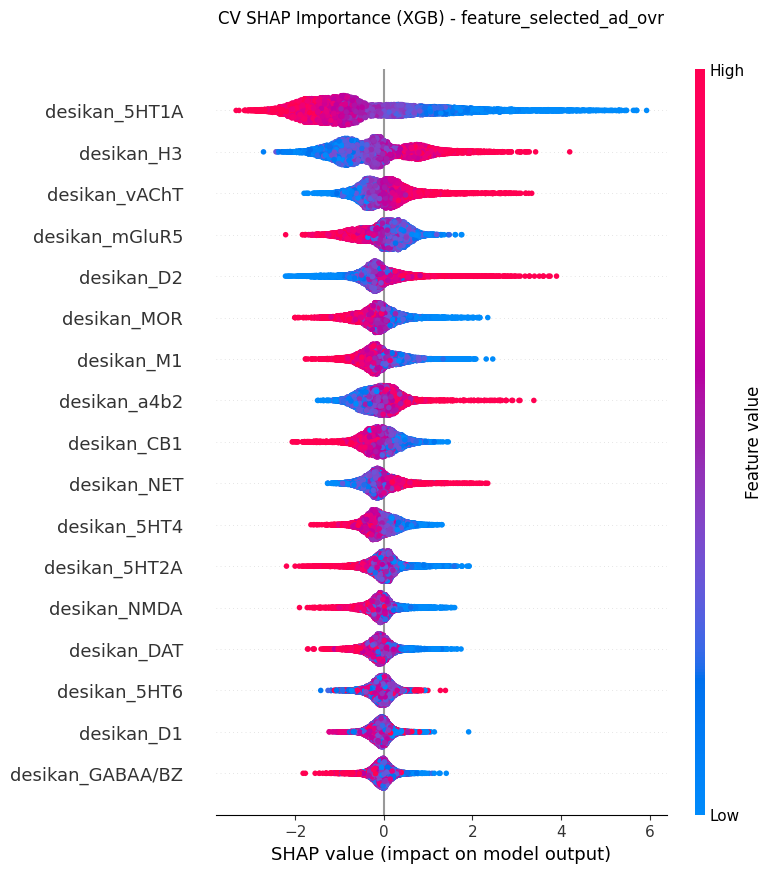

{'Feature_selected_ad_ovr LR accuracy': [0.7921207041072925, 0.7492662473794549, 0.7651991614255765, 0.8012578616352202, 0.8138364779874214], 'Feature_selected_ad_ovr XGB accuracy': [0.8034367141659682, 0.7714884696016772, 0.7752620545073375, 0.8121593291404612, 0.8109014675052411], 'Feature_selected_ad_ovr LR F1': [0.6560332871012483, 0.6358099878197321, 0.6180081855388813, 0.6325581395348837, 0.6035714285714285], 'Feature_selected_ad_ovr XGB F1': [0.6035502958579881, 0.5905334335086401, 0.5592105263157895, 0.5805243445692884, 0.5257623554153522], 'Feature_selected_ad_ovr LR Sensitivity': [0.7962962962962963, 0.7653958944281525, 0.798941798941799, 0.807920792079208, 0.6940451745379876], 'Feature_selected_ad_ovr XGB Sensitivity': [0.601010101010101, 0.5762463343108505, 0.599647266313933, 0.6138613861386139, 0.5133470225872689], 'Feature_selected_ad_ovr LR AUC-PR': [0.7250949705510018, 0.7044644450929881, 0.6681237682131724, 0.6800618892043943, 0.6206816970489686], 'Feature_selected_ad_

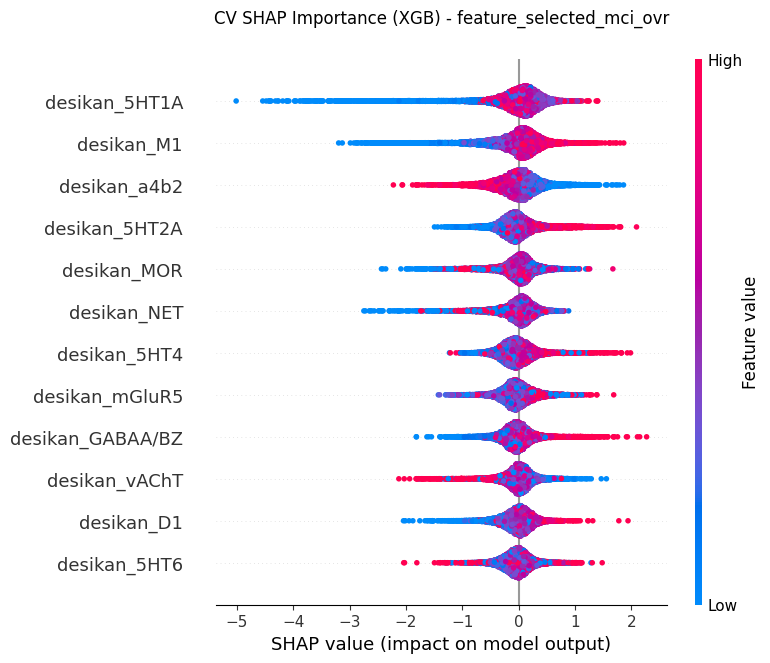

{'Feature_selected_mci_ovr LR accuracy': [0.5088013411567477, 0.5610062893081761, 0.5345911949685535, 0.5568134171907757, 0.49350104821802937], 'Feature_selected_mci_ovr XGB accuracy': [0.5452640402347024, 0.5639412997903563, 0.529140461215933, 0.5169811320754717, 0.5224318658280922], 'Feature_selected_mci_ovr LR F1': [0.4243614931237721, 0.5163972286374134, 0.48467966573816157, 0.5496378355347252, 0.4664310954063604], 'Feature_selected_mci_ovr XGB F1': [0.46735395189003437, 0.4980694980694981, 0.4529956161714564, 0.4434782608695652, 0.4441190824792582], 'Feature_selected_mci_ovr LR Sensitivity': [0.4726477024070022, 0.5792746113989637, 0.5067961165048543, 0.6044985941893158, 0.4888888888888889], 'Feature_selected_mci_ovr XGB Sensitivity': [0.5207877461706784, 0.5347150259067357, 0.45145631067961167, 0.4301780693533271, 0.4212962962962963], 'Feature_selected_mci_ovr LR AUC-PR': [0.4032215889497358, 0.48313134149023396, 0.46955642226792055, 0.5180999193491579, 0.46827598247289437], 'Fea

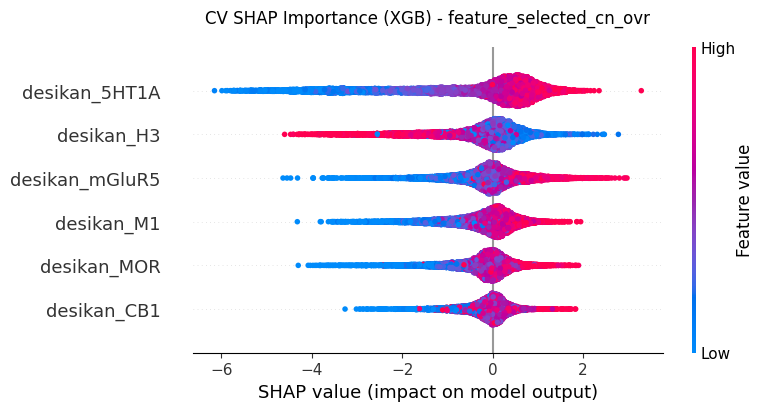

{'Feature_selected_cn_ovr LR accuracy': [0.7129086336965633, 0.7194968553459119, 0.7044025157232704, 0.6612159329140461, 0.6104821802935011], 'Feature_selected_cn_ovr XGB accuracy': [0.6906957250628667, 0.6867924528301886, 0.6792452830188679, 0.6616352201257861, 0.6310272536687631], 'Feature_selected_cn_ovr LR F1': [0.6724055475848876, 0.6322155030236394, 0.6295323173935891, 0.6104146576663452, 0.5763793889648883], 'Feature_selected_cn_ovr XGB F1': [0.5945054945054945, 0.5508117859290439, 0.5641025641025641, 0.5654281098546042, 0.5501022494887525], 'Feature_selected_cn_ovr LR Sensitivity': [0.8006833712984055, 0.7791327913279132, 0.7601522842639594, 0.7785977859778598, 0.7726161369193154], 'Feature_selected_cn_ovr XGB Sensitivity': [0.6161731207289294, 0.6205962059620597, 0.6281725888324873, 0.6457564575645757, 0.6577017114914425], 'Feature_selected_cn_ovr LR AUC-PR': [0.6217062256048029, 0.5728744015862413, 0.573517183977267, 0.49125075694204906, 0.49594788294923803], 'Feature_selecte

In [3]:
import pandas as pd
import numpy as np
import os
import sklearn
import shap
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import precision_recall_curve, auc, accuracy_score, f1_score, recall_score, average_precision_score
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from matplotlib import font_manager

font_path = "/rds/general/user/sk4724/home/arial.ttf"
font_manager.fontManager.addfont(font_path)

df = pd.read_csv('/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/sbm_w_vbm_scott10k_alliedhealth.csv', low_memory = False)

selected_cols = ['desikan_D1', 'desikan_D2', 'desikan_DAT', 'desikan_NET', 'desikan_5HT1A', 'desikan_5HT1B', 'desikan_5HT2A', 'desikan_5HT4', 'desikan_5HT6', 'desikan_5HTT', 'desikan_a4b2', 'desikan_M1', 'desikan_vAChT', 'desikan_NMDA',	'desikan_mGluR5', 'desikan_GABAA/BZ', 'desikan_H3', 'desikan_CB1', 'desikan_MOR']

df = df[['DIAGNOSIS'] + selected_cols].dropna()

print(df['DIAGNOSIS'].value_counts())

assert df.isna().values.any() == False

## OvR - AD vs non-AD

ad_ovr_df = df.copy()
ad_ovr_df['DIAGNOSIS'] = ad_ovr_df['DIAGNOSIS'].apply(lambda x: 1 if x == 3 else 0)
print(ad_ovr_df['DIAGNOSIS'].value_counts())

ad_ovr_X = ad_ovr_df.drop(columns = 'DIAGNOSIS')
ad_ovr_y = ad_ovr_df['DIAGNOSIS']

## OvR - MCI vs non-MCI

mci_ovr_df = df.copy()
mci_ovr_df['DIAGNOSIS'] = mci_ovr_df['DIAGNOSIS'].apply(lambda x: 1 if x == 2 else 0)
print(mci_ovr_df['DIAGNOSIS'].value_counts())

mci_ovr_X = mci_ovr_df.drop(columns = 'DIAGNOSIS')
mci_ovr_y = mci_ovr_df['DIAGNOSIS']

## OvR - CN vs non-CN

cn_ovr_df = df.copy()
cn_ovr_df['DIAGNOSIS'] = cn_ovr_df['DIAGNOSIS'].apply(lambda x: x if x == 1 else 0)
print(cn_ovr_df['DIAGNOSIS'].value_counts())

cn_ovr_X = cn_ovr_df.drop(columns = 'DIAGNOSIS')
cn_ovr_y = cn_ovr_df['DIAGNOSIS']

scaler = StandardScaler()

seed = 42

kf = KFold()

lr = LogisticRegression(random_state = seed, class_weight = 'balanced')

for X, y, selected_cols, flag in [(ad_ovr_X,
                                   ad_ovr_y,
                                    ['desikan_D1', 'desikan_D2', 'desikan_DAT', 'desikan_NET', 'desikan_5HT1A', 'desikan_5HT2A', 'desikan_5HT4', 'desikan_5HT6', 'desikan_a4b2', 'desikan_M1', 'desikan_vAChT', 'desikan_NMDA', 'desikan_mGluR5', 'desikan_GABAA/BZ', 'desikan_H3', 'desikan_CB1', 'desikan_MOR'],
                                    'feature_selected_ad_ovr'),
                                  (mci_ovr_X,
                                   mci_ovr_y,
                                   ['desikan_D1', 'desikan_NET', 'desikan_5HT1A', 'desikan_5HT2A', 'desikan_5HT4', 'desikan_5HT6', 'desikan_a4b2', 'desikan_M1', 'desikan_vAChT', 'desikan_mGluR5', 'desikan_GABAA/BZ', 'desikan_MOR'],
                                   'feature_selected_mci_ovr'),
                                  (cn_ovr_X,
                                   cn_ovr_y,
                                   ['desikan_5HT1A', 'desikan_M1', 'desikan_mGluR5', 'desikan_H3', 'desikan_CB1','desikan_MOR'],
                                   'feature_selected_cn_ovr')]:

    X = X[selected_cols]

    xgb_balancer = float(y[y == 0].shape[0])/ float(y[y == 1].shape[0])
    print(xgb_balancer)

    ## Instantiate xgb with the balancer - mitigates class imbalance

    xgb = XGBClassifier(random_state = seed, scale_pos_weight = xgb_balancer)

    accuracies_lr = []
    f1_scores_lr = []
    sensitivities_lr = []
    aucprs_lr = []
    
    accuracies_xgb = []
    f1_scores_xgb = []
    sensitivities_xgb = []
    aucprs_xgb = []

    list_test_sets = list()
    
    list_shap_values_xgb = list()
    
    list_X_test_scaled = []

    for i, (train_index, test_index) in enumerate(kf.split(X)):
        print(f"Fold {i}:")
    
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train,y_test = y.iloc[train_index], y.iloc[test_index]
    
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
        list_X_test_scaled.append(X_test)
            
        lr.fit(X_train, y_train)
        xgb.fit(X_train, y_train)

        lr_pred_diags = lr.predict(X_test)
        xgb_pred_diags = xgb.predict(X_test)
    
        lr_pred_probas = lr.predict_proba(X_test)[:,1]
        xgb_pred_probas = xgb.predict_proba(X_test)[:,1]
    
        precision_lr, recall_lr, thresholds_lr = precision_recall_curve(y_test, lr_pred_probas)
        precision_xgb, recall_xgb, thresholds_xgb = precision_recall_curve(y_test, xgb_pred_probas)
            
        aucpr_lr = auc(recall_lr, precision_lr)
        aucprs_lr.append(aucpr_lr)
        aucpr_xgb = auc(recall_xgb, precision_xgb)
        aucprs_xgb.append(aucpr_xgb)

        
        acc_lr = accuracy_score(y_test, lr_pred_diags)
        accuracies_lr.append(acc_lr)
        acc_xgb = accuracy_score(y_test, xgb_pred_diags)
        accuracies_xgb.append(acc_xgb)
        
        f1_lr = f1_score(y_test, lr_pred_diags)
        f1_scores_lr.append(f1_lr)
        f1_xgb = f1_score(y_test, xgb_pred_diags)
        f1_scores_xgb.append(f1_xgb)

        sensitivity_lr = recall_score(y_test, lr_pred_diags)
        sensitivities_lr.append(sensitivity_lr)
        sensitivity_xgb = recall_score(y_test, xgb_pred_diags)
        sensitivities_xgb.append(sensitivity_xgb)
    
        list_test_sets.append(test_index)# A list of the order of test set indexes
    
        xgb_explainer = shap.TreeExplainer(xgb)
        xgb_shap_values = xgb_explainer.shap_values(X_test)
        list_shap_values_xgb.append(xgb_shap_values) # A list of shap values
        
    test_set = list_test_sets[0]
    shap_values_xgb = np.array(list_shap_values_xgb[0])
    
    X_scaled_full = np.concatenate(list_X_test_scaled, axis=0)
    for n in range(1,len(list_test_sets)):
        test_set = np.concatenate((test_set,list_test_sets[n]),axis=0)
        print(test_set)
        shap_values_xgb = np.concatenate((shap_values_xgb, np.array(list_shap_values_xgb[n])),axis = 0)
    
    print('FEATURE SELECTED XGB SHAP INCOMING...')
    print(shap_values_xgb.shape)
    X_reordered = X.iloc[test_set]
    shap.summary_plot(shap_values_xgb, X_reordered, show=False)    
    plt.title(f'CV SHAP Importance (XGB) - {flag}', y=1.05)
    plt.savefig(f'/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/classifiers/feature_selected_xgb_shap_beeswarm_{flag}.png',dpi=600)
    plt.show()
    plt.close()



    flag_u = flag.capitalize()
    
    data = {
        f"{flag_u} LR accuracy": accuracies_lr,
        f"{flag_u} XGB accuracy": accuracies_xgb,
        f"{flag_u} LR F1": f1_scores_lr,
        f"{flag_u} XGB F1": f1_scores_xgb,
        f"{flag_u} LR Sensitivity": sensitivities_lr,
        f"{flag_u} XGB Sensitivity": sensitivities_xgb,
        f"{flag_u} LR AUC-PR": aucprs_lr,
        f"{flag_u} XGB AUC-PR": aucprs_xgb}

    print(data)
    
    for key, vals in data.items():
        print(key, len(vals))
    
    df = pd.DataFrame(data)
    
    print(df)
    
    df.to_csv(f'/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/classifiers/feature_selected_fold_metrics_{flag}.csv', index = False)
            

In [4]:
import pandas as pd
import numpy as np
import os
import scipy
from scipy.stats import wilcoxon

files = ['feature_selected_fold_metrics_feature_selected_ad_ovr', 'feature_selected_fold_metrics_feature_selected_mci_ovr', 'feature_selected_fold_metrics_feature_selected_cn_ovr']

for file in files:

    df = pd.read_csv(os.path.join(f'/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/classifiers/{file}.csv'), low_memory = False)

    accuracies = df[[col for col in df.columns.tolist() if 'accuracy' in col]]
    f1s = df[[col for col in df.columns.tolist() if 'F1' in col]]
    sensitivities = df[[col for col in df.columns.tolist() if 'Sensitivity' in col]]
    aucprs = df[[col for col in df.columns.tolist() if 'AUC-PR' in col]]

    thresh = len([accuracies, f1s, sensitivities, aucprs])
    
    for n in [accuracies, f1s, sensitivities, aucprs]:
        print(n)
        print(n.values[:,0], n.values[:,1])
        res = wilcoxon(n.values[:,0], n.values[:,1])
        print(f'Raw p-value = {res.pvalue}. Adjusted by n = 12 : {float(res.pvalue * (thresh * 3))}. Adjusted by n = 4: {float(res.pvalue * thresh)}')
        print(bool(float(res.pvalue * (thresh * 3)) < 0.05)) # Prints adjusted p value. Threshold is 12 - more strict
        print(bool(float(res.pvalue * thresh) < 0.05))# Prints adjusted p value. Threshold is 4 - for each set of metrics
        print(' ')

   Feature_selected_ad_ovr LR accuracy  Feature_selected_ad_ovr XGB accuracy
0                             0.792121                              0.803437
1                             0.749266                              0.771488
2                             0.765199                              0.775262
3                             0.801258                              0.812159
4                             0.813836                              0.810901
[0.7921207  0.74926625 0.76519916 0.80125786 0.81383648] [0.80343671 0.77148847 0.77526205 0.81215933 0.81090147]
Raw p-value = 0.125. Adjusted by n = 12 : 1.5. Adjusted by n = 4: 0.5
False
False
 
   Feature_selected_ad_ovr LR F1  Feature_selected_ad_ovr XGB F1
0                       0.656033                        0.603550
1                       0.635810                        0.590533
2                       0.618008                        0.559211
3                       0.632558                        0.580524
4              